In [1]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =============================================================================
#  E-Commerce Product Demand Prediction using Machine Learning
#  Engineering Student Project
#  Dataset: Indian E-Commerce Pricing & Revenue (36 Months)
#  Target Variable: units_sold
#  Models: Linear Regression | Support Vector Regression (SVR - RBF Kernel)
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 : IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# =============================================================================
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 : LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────
# =============================================================================

print("=" * 60)
print("SECTION 1 : Loading Dataset")
print("=" * 60)

# ── Update this path if the CSV is stored somewhere else ──────────────────────
CSV_PATH = "E:\\ML\\market_demand_analysis_of_e_commerce\\Dataset\\indian_ecommerce_pricing_revenue_growth_36_months (1).csv"

df = pd.read_csv(CSV_PATH)

print(f"\n✔  Dataset loaded successfully!")
print(f"   Rows   : {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")
print(f"\nFirst 3 rows:\n{df.head(3)}")
print(f"\nData Types:\n{df.dtypes}")

SECTION 1 : Loading Dataset

✔  Dataset loaded successfully!
   Rows   : 30,600
   Columns: 16

First 3 rows:
     order_id  order_date        state   zone            category brand_type  \
0  ORD0000001  2023-01-31  West Bengal   East             Fashion       Mass   
1  ORD0000002  2023-01-31      Gujarat   West    Sports & Fitness       Mass   
2  ORD0000003  2023-01-31    Delhi NCR  North  Grocery Essentials       Mass   

  customer_gender  customer_age  base_price  discount_percent  final_price  \
0            Male            28     1810.89             65.00       633.81   
1            Male            19     5678.15             50.83      2791.95   
2            Male            25      169.98             35.26       110.05   

   units_sold    revenue sales_event competition_intensity inventory_pressure  
0          29   18380.49      Normal                Medium               High  
1          67  187060.65      Normal                Medium               High  
2          57   

In [4]:
# =============================================================================
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 : PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 2 : Preprocessing")
print("=" * 60)

# ── 2a. Select only the columns needed for this project ──────────────────────
#    Features (X): category, brand_type, zone, sales_event +
#                  base_price, discount_percent, final_price, customer_age
#    Target  (Y): units_sold

CATEGORICAL_COLS = ["category", "brand_type", "zone", "sales_event"]
NUMERICAL_COLS   = ["base_price", "discount_percent", "final_price", "customer_age"]
TARGET_COL       = "units_sold"

# Keep only relevant columns
data = df[CATEGORICAL_COLS + NUMERICAL_COLS + [TARGET_COL]].copy()

# Check for missing values
print(f"\nMissing values:\n{data.isnull().sum()}")
data.dropna(inplace=True)   # drop any rows with NaN (safety step)
print(f"\nRows after cleaning: {len(data):,}")

# ── 2b. One-Hot Encoding for categorical columns ──────────────────────────────
#    One-Hot Encoding converts:  "North" → [1,0,0,0,0]
#                                "South" → [0,1,0,0,0]  … etc.
#    drop_first=True avoids the "dummy variable trap" (multicollinearity)

data_encoded = pd.get_dummies(data, columns=CATEGORICAL_COLS, drop_first=True)
print(f"\nShape after One-Hot Encoding: {data_encoded.shape}")

# ── 2c. Define X (features) and Y (target) ───────────────────────────────────
X = data_encoded.drop(columns=[TARGET_COL])
Y = data_encoded[TARGET_COL]

print(f"\nFeature matrix X shape : {X.shape}")
print(f"Target vector  Y shape : {Y.shape}")

# ── 2d. Train / Test Split  (80 : 20) ────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)
print(f"\nTraining set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

# ── 2e. Normalise numerical columns with StandardScaler ──────────────────────
#    StandardScaler → z = (x − mean) / std
#    This prevents large-magnitude features from dominating SVR.
#    IMPORTANT: fit only on training data to avoid data leakage.

scaler = StandardScaler()

# Identify which columns (after encoding) correspond to original numerics
num_cols_in_X = [c for c in X_train.columns if c in NUMERICAL_COLS]

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols_in_X] = scaler.fit_transform(X_train[num_cols_in_X])
X_test_scaled[num_cols_in_X]  = scaler.transform(X_test[num_cols_in_X])

print(f"\n✔  Scaling applied to: {num_cols_in_X}")


SECTION 2 : Preprocessing

Missing values:
category            0
brand_type          0
zone                0
sales_event         0
base_price          0
discount_percent    0
final_price         0
customer_age        0
units_sold          0
dtype: int64

Rows after cleaning: 30,600

Shape after One-Hot Encoding: (30600, 18)

Feature matrix X shape : (30600, 17)
Target vector  Y shape : (30600,)

Training set : 24,480 rows
Test set     : 6,120 rows

✔  Scaling applied to: ['base_price', 'discount_percent', 'final_price', 'customer_age']


In [5]:
# =============================================================================
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 : TRAIN MODELS
# ─────────────────────────────────────────────────────────────────────────────
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 3 : Training Models")
print("=" * 60)

# ── Model 1 : Linear Regression ──────────────────────────────────────────────
#    Finds the hyperplane (best-fit line in n-D space) that minimises RSS.
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, Y_train)
Y_pred_lr = lr_model.predict(X_test_scaled)
print("\n✔  Linear Regression trained.")

# ── Model 2 : SVR with RBF Kernel ────────────────────────────────────────────
#    SVR finds a tube of width ε around the fit; points inside the tube
#    are NOT penalised.  RBF kernel handles non-linear patterns.
#    C   = regularisation (higher C → less tolerance for errors)
#    eps = ε-tube half-width
#    gamma='scale' → γ = 1 / (n_features × X.var())
svr_model = SVR(kernel="rbf", C=100, epsilon=0.5, gamma="scale")
svr_model.fit(X_train_scaled, Y_train)
Y_pred_svr = svr_model.predict(X_test_scaled)
print("✔  SVR (RBF Kernel) trained.")



SECTION 3 : Training Models

✔  Linear Regression trained.
✔  SVR (RBF Kernel) trained.


In [6]:
# =============================================================================
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 : EVALUATE MODELS
# ─────────────────────────────────────────────────────────────────────────────
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 4 : Model Evaluation")
print("=" * 60)

def evaluate(name, y_true, y_pred):
    """Print MAE, MSE, RMSE, R² for a given model."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f" {name}")
    print(f"{'─'*40}")
    print(f"  MAE  (Mean Absolute Error)       : {mae:.4f}")
    print(f"  MSE  (Mean Squared Error)         : {mse:.4f}")
    print(f"  RMSE (Root Mean Squared Error)    : {rmse:.4f}")
    print(f"  R²   Score                        : {r2:.4f}")
    return mae, mse, rmse, r2

lr_mae,  lr_mse,  lr_rmse,  lr_r2  = evaluate("Linear Regression", Y_test, Y_pred_lr)
svr_mae, svr_mse, svr_rmse, svr_r2 = evaluate("SVR (RBF Kernel)",  Y_test, Y_pred_svr)


SECTION 4 : Model Evaluation

────────────────────────────────────────
 Linear Regression
────────────────────────────────────────
  MAE  (Mean Absolute Error)       : 13.3367
  MSE  (Mean Squared Error)         : 283.8068
  RMSE (Root Mean Squared Error)    : 16.8466
  R²   Score                        : 0.3549

────────────────────────────────────────
 SVR (RBF Kernel)
────────────────────────────────────────
  MAE  (Mean Absolute Error)       : 13.3003
  MSE  (Mean Squared Error)         : 285.5472
  RMSE (Root Mean Squared Error)    : 16.8981
  R²   Score                        : 0.3510


In [7]:

# =============================================================================
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 : VISUALISATIONS
# ─────────────────────────────────────────────────────────────────────────────
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 5 : Plotting Graphs (each shown separately)")
print("=" * 60)

# Use a limited sample for scatter plots so they are readable
SAMPLE_N = 300
idx = np.random.choice(len(Y_test), size=SAMPLE_N, replace=False)
y_true_sample    = np.array(Y_test)[idx]
y_pred_lr_sample = Y_pred_lr[idx]
y_pred_svr_sample= Y_pred_svr[idx]



SECTION 5 : Plotting Graphs (each shown separately)


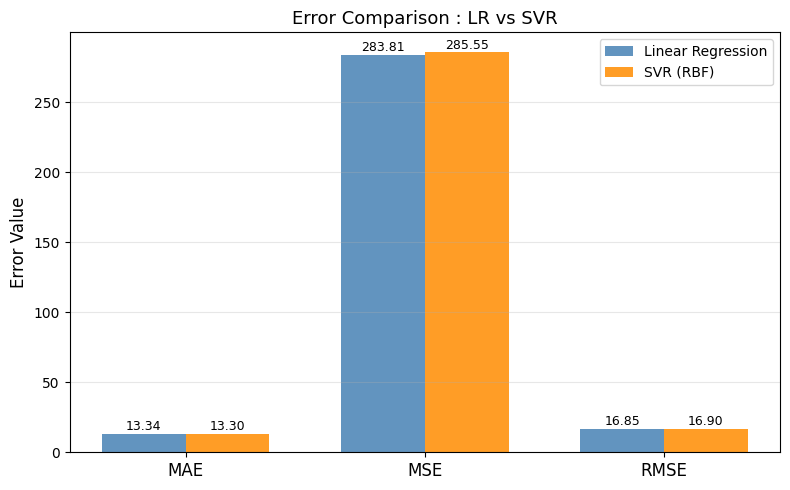

In [8]:
# ── Graph 6 : Error Comparison ────────────────────────────────────────────────
metrics     = ["MAE", "MSE", "RMSE"]
lr_errors   = [lr_mae, lr_mse, lr_rmse]
svr_errors  = [svr_mae, svr_mse, svr_rmse]
x_pos = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x_pos - width/2, lr_errors,  width, label="Linear Regression", color="steelblue",  alpha=0.85)
bars2 = ax.bar(x_pos + width/2, svr_errors, width, label="SVR (RBF)",          color="darkorange", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Error Value", fontsize=12)
ax.set_title("Error Comparison : LR vs SVR", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

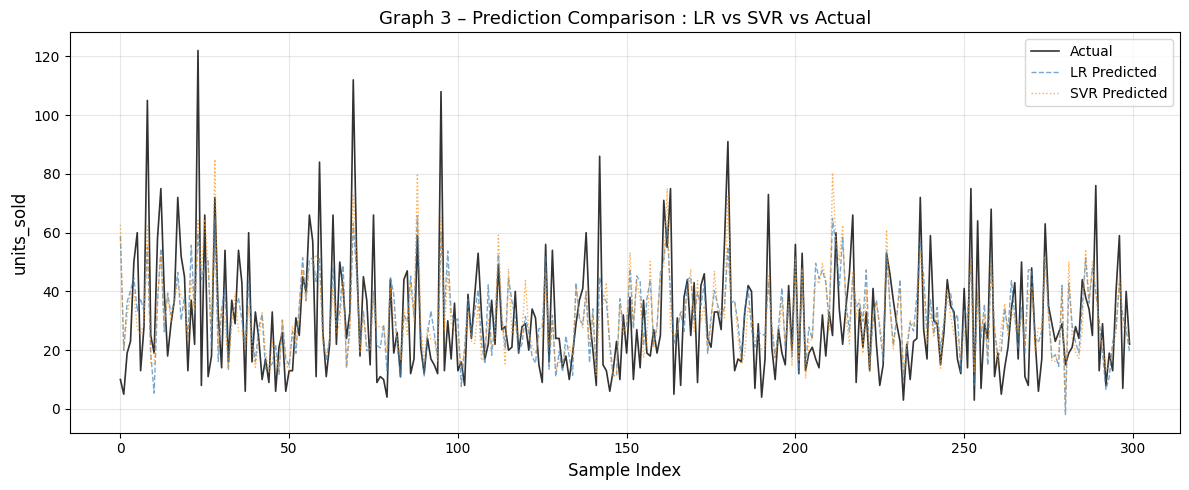

In [9]:
# ── Graph 3 : Prediction Comparison ─────────────────────────────────────────
x_axis = np.arange(SAMPLE_N)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_axis, y_true_sample,    color="black",      lw=1.2, label="Actual",               alpha=0.8)
ax.plot(x_axis, y_pred_lr_sample, color="steelblue",  lw=1.0, label="LR Predicted",  alpha=0.7, linestyle="--")
ax.plot(x_axis, y_pred_svr_sample,color="darkorange",  lw=1.0, label="SVR Predicted", alpha=0.7, linestyle=":")
ax.set_xlabel("Sample Index", fontsize=12)
ax.set_ylabel("units_sold", fontsize=12)
ax.set_title("Graph 3 – Prediction Comparison : LR vs SVR vs Actual", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

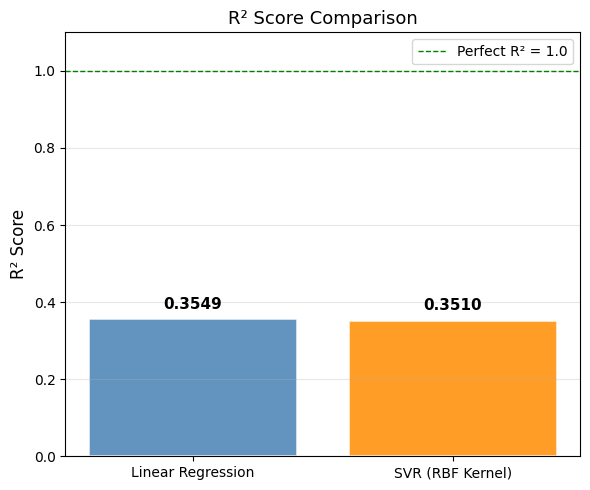

In [10]:
# ── Graph 7 : R² Score Comparison ────────────────────────────────────────────
models = ["Linear Regression", "SVR (RBF Kernel)"]
r2_vals = [lr_r2, svr_r2]
colors  = ["steelblue", "darkorange"]
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(models, r2_vals, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
ax.set_ylim(0, 1.1)
ax.set_ylabel("R² Score", fontsize=12)
ax.set_title("R² Score Comparison", fontsize=13)
ax.axhline(1.0, color="green", linestyle="--", lw=1, label="Perfect R² = 1.0")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
# =============================================================================
# SECTION 4A : TYPE 1 ERROR & TYPE 2 ERROR ANALYSIS
# =============================================================================

print("\n" + "=" * 60)
print("SECTION 4A : Type 1 & Type 2 Error Analysis")
print("=" * 60)

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score
)

# -----------------------------------------------------------------------------
# STEP 1 : Convert Regression Predictions into Classification Labels
# -----------------------------------------------------------------------------
# High Demand = units_sold >= threshold
# Low Demand  = units_sold < threshold

THRESHOLD = 30

print(f"\nDemand Threshold = {THRESHOLD} units")

# Actual labels
Y_test_class = np.where(Y_test >= THRESHOLD, 1, 0)

# Predicted labels - Linear Regression
Y_pred_lr_class = np.where(Y_pred_lr >= THRESHOLD, 1, 0)

# Predicted labels - SVR
Y_pred_svr_class = np.where(Y_pred_svr >= THRESHOLD, 1, 0)

# -----------------------------------------------------------------------------
# STEP 2 : Confusion Matrix
# -----------------------------------------------------------------------------

cm_lr = confusion_matrix(Y_test_class, Y_pred_lr_class)
cm_svr = confusion_matrix(Y_test_class, Y_pred_svr_class)

# -----------------------------------------------------------------------------
# STEP 3 : Extract TP, TN, FP, FN
# -----------------------------------------------------------------------------

# Linear Regression
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

# SVR
tn_svr, fp_svr, fn_svr, tp_svr = cm_svr.ravel()

# -----------------------------------------------------------------------------
# STEP 4 : Calculate Metrics
# -----------------------------------------------------------------------------

# ----- Linear Regression -----
precision_lr = precision_score(Y_test_class, Y_pred_lr_class)
recall_lr    = recall_score(Y_test_class, Y_pred_lr_class)
accuracy_lr  = accuracy_score(Y_test_class, Y_pred_lr_class)
f1_lr        = f1_score(Y_test_class, Y_pred_lr_class)

# ----- SVR -----
precision_svr = precision_score(Y_test_class, Y_pred_svr_class)
recall_svr    = recall_score(Y_test_class, Y_pred_svr_class)
accuracy_svr  = accuracy_score(Y_test_class, Y_pred_svr_class)
f1_svr        = f1_score(Y_test_class, Y_pred_svr_class)

# -----------------------------------------------------------------------------
# STEP 5 : Display Results
# -----------------------------------------------------------------------------

def print_results(
    model_name,
    tp,
    tn,
    fp,
    fn,
    precision,
    recall,
    accuracy,
    f1
):

    print("\n" + "─" * 50)
    print(model_name)
    print("─" * 50)

    print(f"True Positives  (TP) : {tp}")
    print(f"True Negatives  (TN) : {tn}")

    print(f"\nFalse Positives (FP) : {fp}")
    print("→ Type 1 Error : Overstocking")

    print(f"\nFalse Negatives (FN) : {fn}")
    print("→ Type 2 Error : Understocking")

    print(f"\nPrecision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"F1 Score  : {f1:.4f}")


print_results(
    "Linear Regression",
    tp_lr,
    tn_lr,
    fp_lr,
    fn_lr,
    precision_lr,
    recall_lr,
    accuracy_lr,
    f1_lr
)

print_results(
    "SVR (RBF Kernel)",
    tp_svr,
    tn_svr,
    fp_svr,
    fn_svr,
    precision_svr,
    recall_svr,
    accuracy_svr,
    f1_svr
)


SECTION 4A : Type 1 & Type 2 Error Analysis

Demand Threshold = 30 units

──────────────────────────────────────────────────
Linear Regression
──────────────────────────────────────────────────
True Positives  (TP) : 1896
True Negatives  (TN) : 2251

False Positives (FP) : 1159
→ Type 1 Error : Overstocking

False Negatives (FN) : 814
→ Type 2 Error : Understocking

Precision : 0.6206
Recall    : 0.6996
Accuracy  : 0.6776
F1 Score  : 0.6578

──────────────────────────────────────────────────
SVR (RBF Kernel)
──────────────────────────────────────────────────
True Positives  (TP) : 1700
True Negatives  (TN) : 2471

False Positives (FP) : 939
→ Type 1 Error : Overstocking

False Negatives (FN) : 1010
→ Type 2 Error : Understocking

Precision : 0.6442
Recall    : 0.6273
Accuracy  : 0.6815
F1 Score  : 0.6356


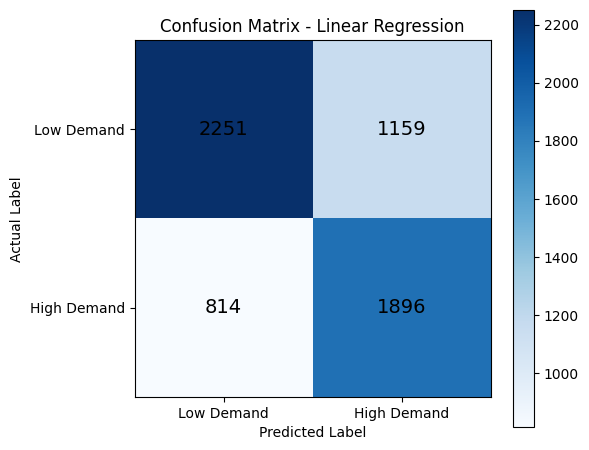

In [12]:
# -----------------------------------------------------------------------------
# GRAPH 1 : Confusion Matrix - Linear Regression
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm_lr, cmap="Blues")

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            cm_lr[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Low Demand", "High Demand"])
ax.set_yticklabels(["Low Demand", "High Demand"])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_title("Confusion Matrix - Linear Regression")

plt.colorbar(im)

plt.tight_layout()
plt.show()



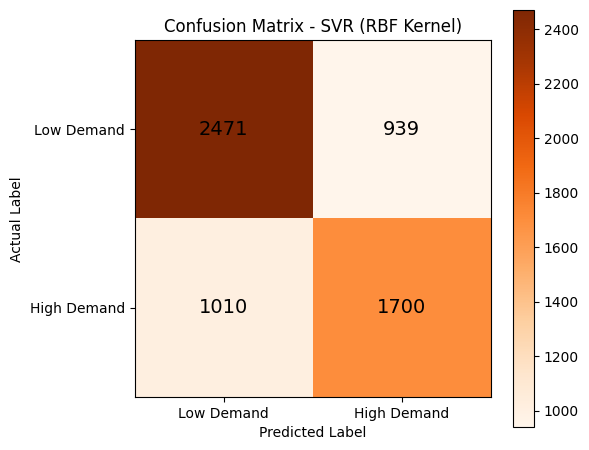

In [13]:
# -----------------------------------------------------------------------------
# GRAPH 2 : Confusion Matrix - SVR
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm_svr, cmap="Oranges")

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            cm_svr[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Low Demand", "High Demand"])
ax.set_yticklabels(["Low Demand", "High Demand"])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_title("Confusion Matrix - SVR (RBF Kernel)")

plt.colorbar(im)

plt.tight_layout()
plt.show()


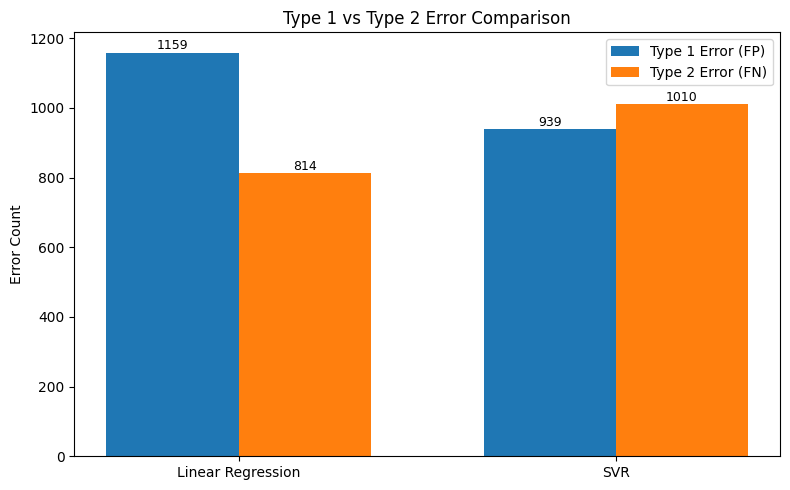

In [14]:
# -----------------------------------------------------------------------------
# GRAPH 3 : Type 1 vs Type 2 Error Comparison
# -----------------------------------------------------------------------------

models = ["Linear Regression", "SVR"]

type1_errors = [fp_lr, fp_svr]
type2_errors = [fn_lr, fn_svr]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width/2,
    type1_errors,
    width,
    label="Type 1 Error (FP)"
)

bars2 = ax.bar(
    x + width/2,
    type2_errors,
    width,
    label="Type 2 Error (FN)"
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylabel("Error Count")

ax.set_title("Type 1 vs Type 2 Error Comparison")

ax.legend()

# Add labels to bars
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

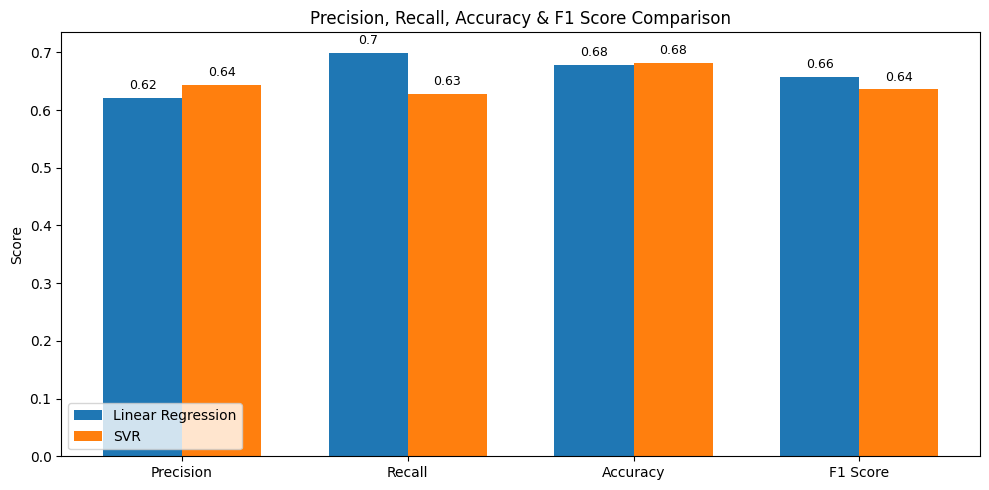

In [15]:
# -----------------------------------------------------------------------------
# GRAPH 4 : Precision, Recall, Accuracy & F1 Score Comparison
# -----------------------------------------------------------------------------

metrics = ["Precision", "Recall", "Accuracy", "F1 Score"]

lr_values = [
    precision_lr,
    recall_lr,
    accuracy_lr,
    f1_lr
]

svr_values = [
    precision_svr,
    recall_svr,
    accuracy_svr,
    f1_svr
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width/2,
    lr_values,
    width,
    label="Linear Regression"
)

bars2 = ax.bar(
    x + width/2,
    svr_values,
    width,
    label="SVR"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylabel("Score")

ax.set_title("Precision, Recall, Accuracy & F1 Score Comparison")

ax.legend()

# Add labels to bars
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

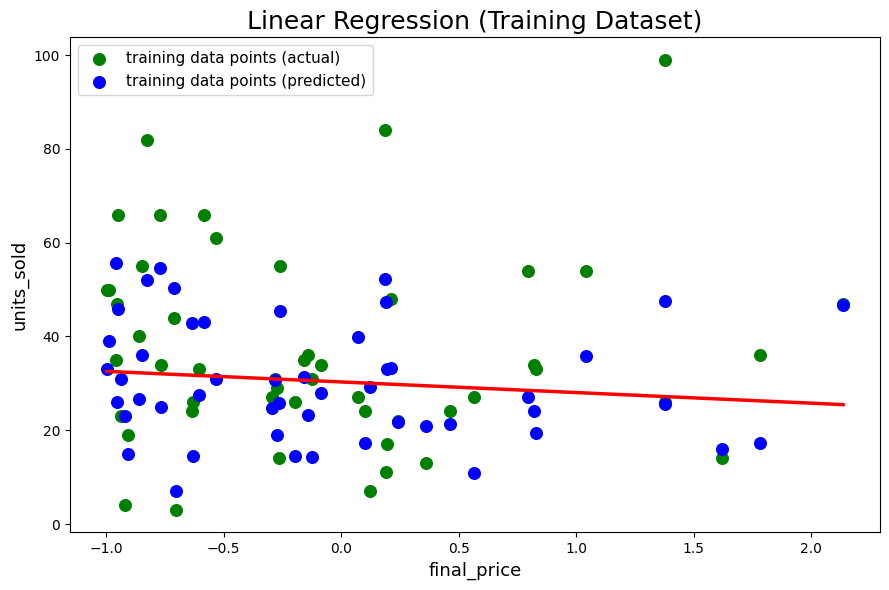

In [16]:
# Linear Regression : Actual vs Predicted using final_price

# Predict values
Y_pred_lr_train = lr_model.predict(X_train_scaled)

# Take few points for clean graph
sample_size = 50

# Use final_price feature
x_feature = X_train_scaled['final_price'].iloc[:sample_size]

# Actual and predicted values
y_actual = Y_train.iloc[:sample_size]
y_pred = Y_pred_lr_train[:sample_size]

# Sort values for proper line plotting
sorted_idx = np.argsort(x_feature)

x_sorted = x_feature.iloc[sorted_idx]
y_actual_sorted = y_actual.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

# Create straight regression line
m, b = np.polyfit(x_sorted, y_pred_sorted, 1)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

# Actual points
ax.scatter(
    x_sorted,
    y_actual_sorted,
    color='green',
    s=70,
    label='training data points (actual)'
)

# Predicted points
ax.scatter(
    x_sorted,
    y_pred_sorted,
    color='blue',
    s=70,
    label='training data points (predicted)'
)

# Straight regression line
ax.plot(
    x_sorted,
    m * x_sorted + b,
    color='red',
    linewidth=2.5
)

# Title and labels
ax.set_title("Linear Regression (Training Dataset)", fontsize=18)
ax.set_xlabel("final_price", fontsize=13)
ax.set_ylabel("units_sold", fontsize=13)

# Legend
ax.legend(fontsize=11)

# Clean look
ax.grid(False)

plt.tight_layout()
plt.show()


[SVM Visualisation] Fitting 1-D SVR on final_price → units_sold ...


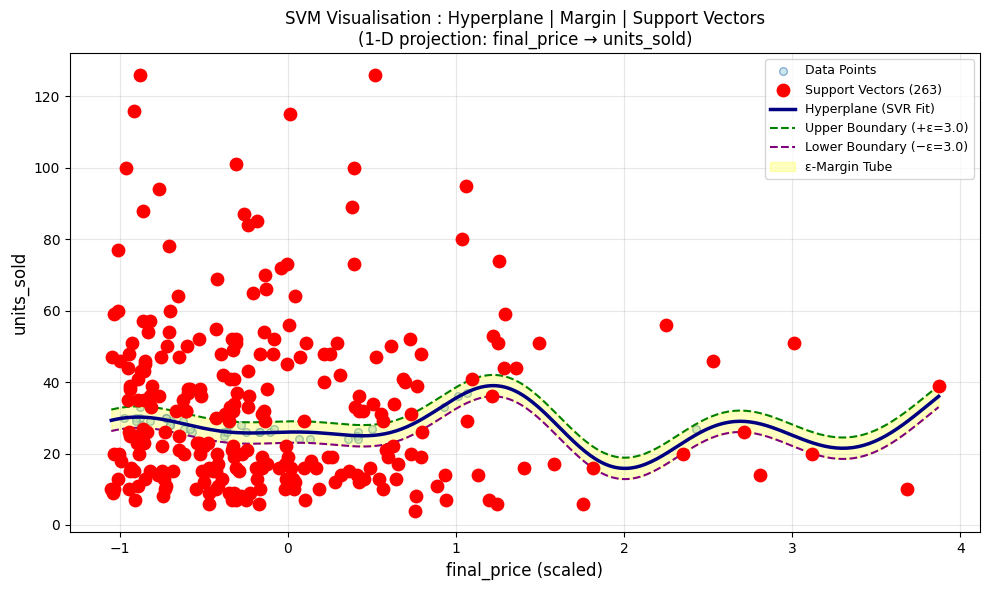

In [17]:
# ── Graph 8 : SVM Visualisation (2-D projection) ─────────────────────────────
#   To visualise the SVR concepts (hyperplane, margins, support vectors)
#   we reduce the data to 1 feature (final_price) vs units_sold.

print("\n[SVM Visualisation] Fitting 1-D SVR on final_price → units_sold ...")

# Use a small sample for clarity
svm_sample_idx = np.random.choice(len(Y_train), size=300, replace=False)
X_svm_1d = np.array(X_train_scaled["final_price"])[svm_sample_idx].reshape(-1, 1)
Y_svm    = np.array(Y_train)[svm_sample_idx]

svr_1d = SVR(kernel="rbf", C=100, epsilon=3, gamma="scale")
svr_1d.fit(X_svm_1d, Y_svm)

# Generate smooth curve for the fitted line
x_range      = np.linspace(X_svm_1d.min(), X_svm_1d.max(), 300).reshape(-1, 1)
y_fit        = svr_1d.predict(x_range)
epsilon_val  = svr_1d.epsilon          # ε-tube half-width

# Support vector indices
sv_indices   = svr_1d.support_

fig, ax = plt.subplots(figsize=(10, 6))

# All data points
ax.scatter(X_svm_1d, Y_svm,
           color="lightblue", edgecolors="steelblue", s=30, alpha=0.6, label="Data Points")

# Highlight support vectors
ax.scatter(X_svm_1d[sv_indices], Y_svm[sv_indices],
           color="red", s=80, zorder=5, label=f"Support Vectors ({len(sv_indices)})")

# Hyperplane (fitted curve)
ax.plot(x_range, y_fit, color="navy", lw=2.5, label="Hyperplane (SVR Fit)")

# Upper and lower ε-boundaries
ax.plot(x_range, y_fit + epsilon_val, color="green",  lw=1.5, linestyle="--", label=f"Upper Boundary (+ε={epsilon_val:.1f})")
ax.plot(x_range, y_fit - epsilon_val, color="purple", lw=1.5, linestyle="--", label=f"Lower Boundary (−ε={epsilon_val:.1f})")

# Fill the margin tube
ax.fill_between(x_range.ravel(), y_fit - epsilon_val, y_fit + epsilon_val,
                color="yellow", alpha=0.25, label="ε-Margin Tube")

ax.set_xlabel("final_price (scaled)", fontsize=12)
ax.set_ylabel("units_sold", fontsize=12)
ax.set_title("SVM Visualisation : Hyperplane | Margin | Support Vectors\n"
             "(1-D projection: final_price → units_sold)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# ── Valid choices ─────────────────────────────────────────────────────────────
VALID_CATEGORY   = ["Fashion", "Sports & Fitness", "Grocery Essentials",
                    "Footwear", "Home & Living", "Beauty & Personal Care",
                    "Electronics", "Premium Lifestyle"]
VALID_BRAND      = ["Mass", "Premium"]
VALID_ZONE       = ["East", "West", "North", "Central", "South"]
VALID_EVENT      = ["Normal", "Festival"]

def get_choice(prompt, choices):
    """Ask user to pick one value from a list."""
    while True:
        for i, c in enumerate(choices, 1):
            print(f"  {i}. {c}")
        raw = input(f"{prompt} (enter number): ").strip()
        if raw.isdigit() and 1 <= int(raw) <= len(choices):
            return choices[int(raw) - 1]
        print("  ⚠  Invalid choice. Try again.\n")

def get_float(prompt, lo=None, hi=None):
    """Ask user for a float value with optional bounds check."""
    while True:
        raw = input(f"{prompt}: ").strip()
        try:
            val = float(raw)
            if lo is not None and val < lo:
                print(f"  ⚠  Value must be ≥ {lo}")
                continue
            if hi is not None and val > hi:
                print(f"  ⚠  Value must be ≤ {hi}")
                continue
            return val
        except ValueError:
            print("  ⚠  Please enter a valid number.")

print("\nEnter product details below:\n")

category      = get_choice("\ncategory",   VALID_CATEGORY)
brand_type    = get_choice("\nbrand_type", VALID_BRAND)
zone          = get_choice("\nzone",       VALID_ZONE)
sales_event   = get_choice("\nsales_event",VALID_EVENT)

print()
base_price     = get_float("base_price (₹, e.g. 1500)",      lo=1)
discount_pct   = get_float("discount_percent (0–65)",         lo=0, hi=65)

# Calculate final_price automatically
final_price    = base_price * (1 - discount_pct / 100)

customer_age   = get_float("customer_age (18–65)",            lo=18, hi=65)

# ── Build a one-row DataFrame matching the training structure ─────────────────
user_row = {
    "category":         category,
    "brand_type":       brand_type,
    "zone":             zone,
    "sales_event":      sales_event,
    "base_price":       base_price,
    "discount_percent": discount_pct,
    "final_price":      final_price,
    "customer_age":     customer_age,
    TARGET_COL:         0             # placeholder; not used for prediction
}
user_df = pd.DataFrame([user_row])

# Apply the same one-hot encoding as training
user_encoded = pd.get_dummies(user_df, columns=CATEGORICAL_COLS, drop_first=True)

# Align columns with the training feature set (add missing, drop extra)
user_encoded = user_encoded.reindex(columns=X_train.columns, fill_value=0)

# Apply the same scaler
user_scaled                      = user_encoded.copy()
user_scaled[num_cols_in_X]       = scaler.transform(user_encoded[num_cols_in_X])

# ── Make Predictions ──────────────────────────────────────────────────────────
pred_lr  = lr_model.predict(user_scaled)[0]
pred_svr = svr_model.predict(user_scaled)[0]

print("\n" + "=" * 60)
print("  PREDICTION RESULTS")
print("=" * 60)
print(f"\n  Product Details Entered:")
print(f"    Category       : {category}")
print(f"    Brand Type     : {brand_type}")
print(f"    Zone           : {zone}")
print(f"    Sales Event    : {sales_event}")
print(f"    Base Price     : ₹{base_price:,.2f}")
print(f"    Discount       : {discount_pct:.1f}%")
print(f"    Final Price    : ₹{final_price:,.2f} (Calculated)")
print(f"    Customer Age   : {int(customer_age)} years")
print()
print(f"  ┌─────────────────────────────────────────┐")
print(f"  │  Linear Regression Prediction  : {max(0, pred_lr):6.1f}  │")
print(f"  │  SVR (RBF Kernel) Prediction   : {max(0, pred_svr):6.1f}  │")
print(f"  │  Average Prediction            : {max(0,(pred_lr+pred_svr)/2):6.1f}  │")
print(f"  └─────────────────────────────────────────┘")
print(f"\n  (units_sold rounded to nearest whole unit = {max(0, round((pred_lr+pred_svr)/2))})")
plt.figure(figsize=(10, 6))

predictions = [
    max(0, pred_lr),
    max(0, pred_svr),
    max(0, (pred_lr + pred_svr) / 2)
]

import seaborn as sns

# Define PALETTE again to ensure it's accessible in this scope
PALETTE = ["#3d72b8", "#63b393", "#c9663c", "#8e5db5", "#b8873d",
           "#5a9e7a", "#b84d6b", "#4d9ab8"]

plt.figure(figsize=(10, 6))

predictions = [
    max(0, pred_lr),
    max(0, pred_svr),
    max(0, (pred_lr + pred_svr) / 2)
]

labels = ['Linear Regression', 'SVR (RBF Kernel)', 'Average Prediction']

bars = plt.bar(labels, predictions, color=[PALETTE[0], PALETTE[2], PALETTE[1]],
               edgecolor='white', linewidth=0.8, width=0.6)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#333')

plt.title('Predicted Units Sold for User Input')
plt.ylabel('Predicted Units Sold')
plt.xlabel('Prediction Model')
plt.ylim(0, max(predictions) * 1.2) # Adjust y-limit for better visualization
plt.tight_layout()
plt.show()
# =============================================================================
# HIGH DEMAND / LOW DEMAND CLASSIFICATION
# =============================================================================

# Threshold for classification
DEMAND_THRESHOLD = 30

# Linear Regression Demand Label
lr_label = (
    "High Demand"
    if max(0, pred_lr) >= DEMAND_THRESHOLD
    else "Low Demand"
)

# SVR Demand Label
svr_label = (
    "High Demand"
    if max(0, pred_svr) >= DEMAND_THRESHOLD
    else "Low Demand"
)

# Average Prediction Demand Label
avg_prediction = max(0, (pred_lr + pred_svr) / 2)

avg_label = (
    "High Demand"
    if avg_prediction >= DEMAND_THRESHOLD
    else "Low Demand"
)

print("\n" + "=" * 60)
print("  DEMAND CLASSIFICATION")
print("=" * 60)

print(f"\n  Threshold Used : {DEMAND_THRESHOLD} units")

print(f"\n  Linear Regression : {lr_label}")
print(f"  SVR (RBF Kernel)  : {svr_label}")
print(f"  Average Result    : {avg_label}")